# Hard Istance Max Cut with different annealing methods

#### Imports

In [2]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from src.annealing_utils import get_driver_hamiltonian,get_longitudinal_hamiltonian,computational_basis
from src.schedule_utils import SchedulerModel,Schedule
from ManyBodyQutip.qutip_class import SpinOperator 
from src.utils import Sector

## Initialization of the target Hamiltonian

#### Hyperapameters

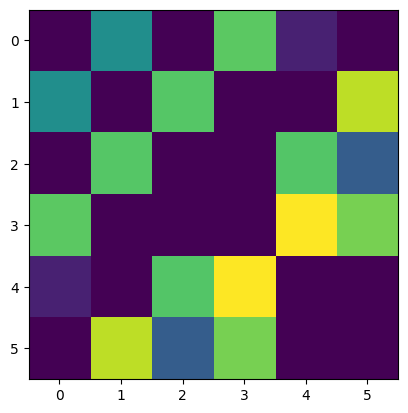

In [5]:
#### create istances on networkx
nqubits = 6

basis=computational_basis(nqubits)
graph_instance = nx.random_regular_graph(d=3, n=nqubits)

# Assign random weights in [0,1]
for u, v in graph_instance.edges():
    graph_instance[u][v]['weight'] = np.random.uniform(0, 1)
    
jij = nx.to_numpy_array(graph_instance)  # unweighted adjacency matrix

plt.imshow(jij)
plt.show()

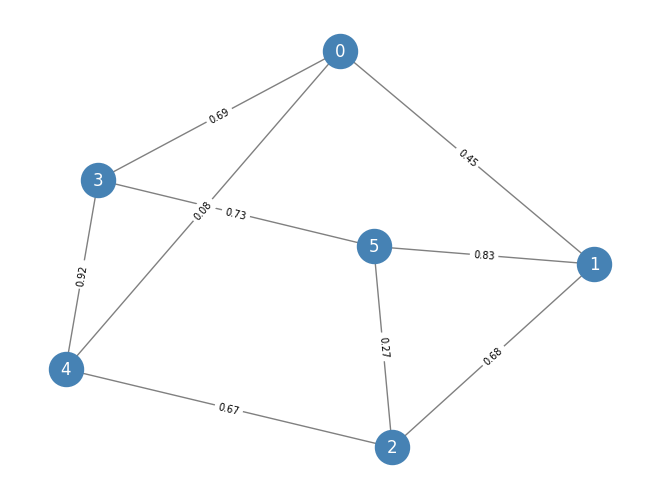

In [6]:

pos = nx.spring_layout(graph_instance, seed=42)
nx.draw(graph_instance, pos, with_labels=True, node_color='steelblue',
        edge_color='gray', node_size=600, font_color='white')

# draw edge weights
edge_labels = {(u,v): f"{graph_instance[u][v]['weight']:.2f}" for u,v in graph_instance.edges()}
nx.draw_networkx_edge_labels(graph_instance, pos, edge_labels=edge_labels, font_size=7)

plt.show()

#### Hamiltonian Initialization

In [7]:
nqubits=jij.shape[0]

PS=Sector(nqubits=nqubits)

target_hamiltonian=get_longitudinal_hamiltonian(jij)
target_hamiltonian_s=PS.project(target_hamiltonian)
driver_hamiltonian=get_driver_hamiltonian(nqubits=nqubits)

driver_hamiltonian_s=PS.project(driver_hamiltonian)


Sector: 32 states out of 64


#### Analysis of the spectrum of the target hamiltonian

/home/ecosta/miniconda3/envs/nsm_gadget_env/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/ecosta/miniconda3/envs/nsm_gadget_env/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


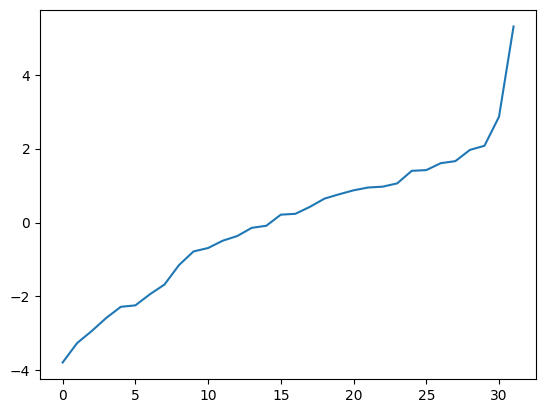

(-3.7898544917092245+0j) (-3.261930136391288+0j) [0 1 1 1 0 0] [0 1 0 1 0 0]


In [8]:
values=target_hamiltonian_s.diagonal()

spectrum_target_hamiltonian_s=np.sort(values)
eigenstates_target_hamiltonian_s=basis[np.argsort(values)]

plt.plot(spectrum_target_hamiltonian_s)
plt.show()

print(spectrum_target_hamiltonian_s[0],spectrum_target_hamiltonian_s[1],eigenstates_target_hamiltonian_s[0],eigenstates_target_hamiltonian_s[1])

#### Time evolution

In [9]:
# ── time evolution parameters ─────────────────────────────────────────────────
nlevels    = 10
tau        = 20
time_steps = int(10 * tau)
time       = np.linspace(0, tau, time_steps)
delta_t    = time[1] - time[0]

In [10]:
from scipy.sparse.linalg import eigsh, expm_multiply

# ── initial state ─────────────────────────────────────────────────────────────
dim      = 2 ** nqubits
psi_init = np.ones(dim, dtype=complex) / np.sqrt(dim)
psi_init=PS.project(psi_init)
print(psi_init.shape)
# ── initialization ────────────────────────────────────────────────────────────
spectrum            = np.zeros((time_steps, nlevels))
energy              = np.zeros(time_steps)
probabilities       = np.zeros((time_steps, nlevels))
psi_history          = np.zeros((time_steps, dim//2), dtype=complex)
eigenstates_history = np.zeros((time_steps, dim//2, nlevels), dtype=complex)

eigenstates_prev = None
psi = psi_init.copy()

# ── time evolution ────────────────────────────────────────────────────────────
for i, t in enumerate(time):
    hamiltonian_t = (1 - t / tau) * driver_hamiltonian_s + (t / tau) * target_hamiltonian_s
    psi = expm_multiply(-1j * delta_t * hamiltonian_t, psi)


    # ── diagonalize ───────────────────────────────────────────────────────
    spectrum_t, eigenstates_t = eigsh(hamiltonian_t.astype(complex), which='SA', k=nlevels)
    order              = np.argsort(spectrum_t)
    spectrum[i]        = spectrum_t[order]
    eigenstates_raw    = eigenstates_t[:, order].astype(complex)  # raw — for probabilities
    eigenstates_history[i] = eigenstates_raw
    # overlap
    probabilities[i]=np.einsum('i,ia->a',psi.conj(),eigenstates_raw)*np.einsum('i,ia->a',psi.conj(),eigenstates_raw).conj()
    energy[i] = np.real(np.vdot(psi, hamiltonian_t @ psi))
    psi_history[i] = psi

print(probabilities[-1])
print(spectrum.shape)
print(time[np.argmin(spectrum[:,2]-spectrum[:,0])],np.min(spectrum[:,2]-spectrum[:,0]))

min_time_gap= time[np.argmin(spectrum[:,2]-spectrum[:,0])]

(32,)


/tmp/ipykernel_73626/3541074027.py:31: ComplexWarning: Casting complex values to real discards the imaginary part
  probabilities[i]=np.einsum('i,ia->a',psi.conj(),eigenstates_raw)*np.einsum('i,ia->a',psi.conj(),eigenstates_raw).conj()


[9.39600314e-01 5.34741854e-02 2.16566793e-03 2.33061873e-03
 1.47827065e-03 4.58690141e-04 3.72682470e-04 2.53272412e-05
 9.80973065e-07 6.15518418e-05]
(200, 10)
18.190954773869347 0.8138465111217923


Check the results

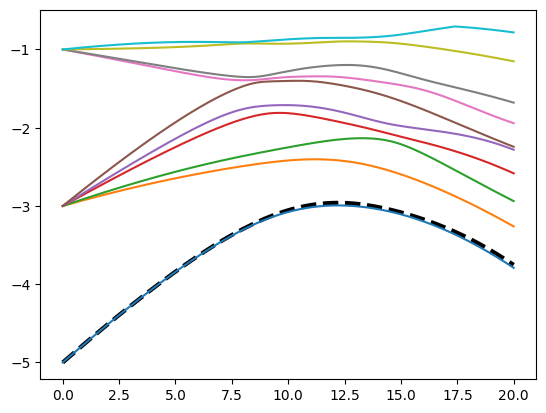

In [11]:

plt.plot(time,energy,color='black',linestyle='--',linewidth=3)
for i in range(spectrum.shape[1]):
        plt.plot(time,spectrum[:,i])

plt.show()

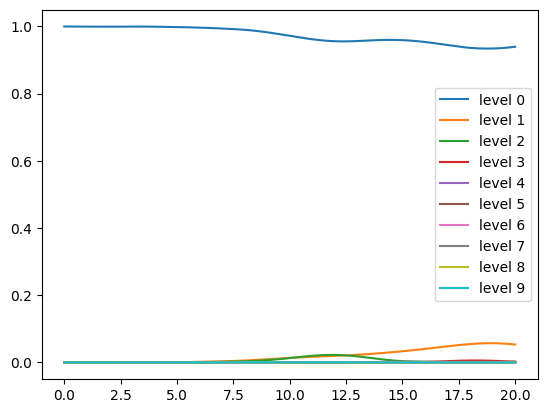

In [12]:
for i in range(nlevels):
    plt.plot(time,probabilities[:,i],label=f'level {i}')

plt.legend()
plt.show()

#### Compute Measure of Stabilizerness

In [13]:
from src.jax_utils import SREJax
from tqdm import trange

# build once — reuse for all states
sre = SREJax(n_qubits=nqubits, batch_size=4096)

# single state
magic=[]
magic_gs_level=[]
for i in trange(time_steps):
    state=psi_history[i]
    magic.append(sre(PS.lift(state)))
    magic_gs_level.append(sre(PS.lift(eigenstates_history[i,:,0])))

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


Building Pauli tables for n=6 (4096 Paulis)...
Done.


100%|██████████| 200/200 [00:00<00:00, 332.47it/s]


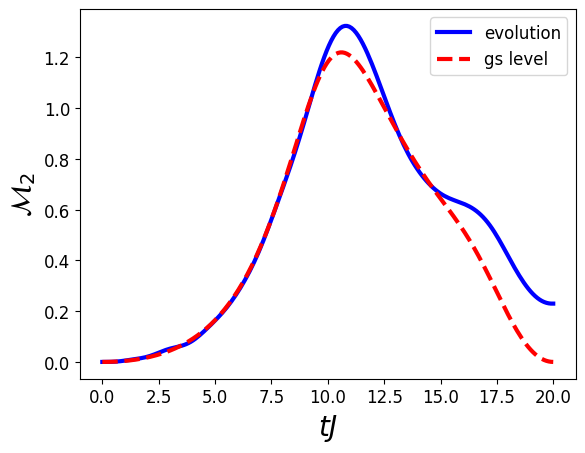

In [14]:
plt.plot(time,magic,label='evolution',color='blue',linestyle='-',linewidth=3)
plt.plot(time,magic_gs_level,label='gs level',color='red',linestyle='--',linewidth=3)
plt.xlabel(r'$t J$',fontsize=20)
plt.ylabel(r'$\mathcal{M}_2$',fontsize=20)
plt.legend(fontsize=12)
plt.tick_params(axis='both', which='major', labelsize=12)
plt.show()

In [15]:

from curses.ascii import SP


_,eigenstates_target_hamiltonian=eigsh(target_hamiltonian_s.astype(complex), which='SA', k=4)
print(sre(PS.lift(eigenstates_target_hamiltonian[:,0]))) 

-8.881784197001252e-16


## Optimal Control Method

##### Get Hyperparameters

In [16]:
number_parameters=5
type='F-CRAB'

In [ ]:
from scipy.optimize import minimize

model=SchedulerModel(target_hamiltonian=target_hamiltonian_s,initial_hamiltonian=driver_hamiltonian_s,tf=tau,nsteps=time_steps,number_of_parameters=number_parameters,type=type,seed=42,reference_hamiltonian=target_hamiltonian_s,mode='annealing ansatz')



res = minimize(
                    model.forward,
                    model.parameters,
                    method='L-BFGS-B',
                    tol=10**-6,
                    callback=model.callback,
                    options=None,
                    
                )

model.parameters = res.x
energy = model.forward(model.parameters)

#### Jax optimization (optional)

In [18]:
from src.jax_utils import JaxSchedulerModel, JaxTrainer

model = JaxSchedulerModel(
    initial_state=psi_init,
    target_hamiltonian=target_hamiltonian_s,
    initial_hamiltonian=driver_hamiltonian_s,
    reference_hamiltonian=target_hamiltonian_s,
    tf=tau,
    nsteps=time_steps,
    number_of_parameters=number_parameters,
    type=type,
    seed=42,
    mode='annealing ansatz',
    random=True,
)

trainer = JaxTrainer(model, maxiter=1000, tol=1e-6, ftol=1e-9, gtol=1e-6, verbose=True)
results = trainer.run()

h_driver  = results['h_driver']
h_target  = results['h_target']
psi_final = results['psi']
energy    = results['energy']   # already in physical units

JIT compilation done.
-0.0766493454209149
-0.23088573291901035
-0.43749174185844364
-0.6376005130788852
-0.7836015787601127
-0.8728558162251376
-1.0144433268015498
-1.06106045839265
-1.1360011944676522
-1.190511585566813
-1.2564243266650674
-1.2904455353252229
-1.3072832029733203
-1.3447067228892786
-1.4247884089789715
-1.462947391521169
-1.5181635398846784
-1.5917611042475899
-1.642483656208082
-1.6518270870199574
-1.6906845837070597
-1.7116208113801474
-1.7317826290966536
-1.7542864531189801
-1.7695781049602224
-1.7744679269945567
-1.7779620170571127
-1.7789187522805965
-1.781559955763768
-1.783285106389704
-1.7877414651365957
-1.794652739691767
-1.8082634698994573
-1.835778996869729
-1.89995514080485
-1.9145545683147287
-1.933746152454807
-1.9500405227336046
-1.9589867671938255
-1.9967771275583739
-2.022237920762359
-2.0306759404164842
-2.052130223748011
-2.0693639818874114
-2.1053285343020054
-2.1210405510129684
-2.132248956163914
-2.14365344805725
-2.156416088927577
-2.16463432853

#### Check the results

(-0.8878272346255458-4.306985953761785j)


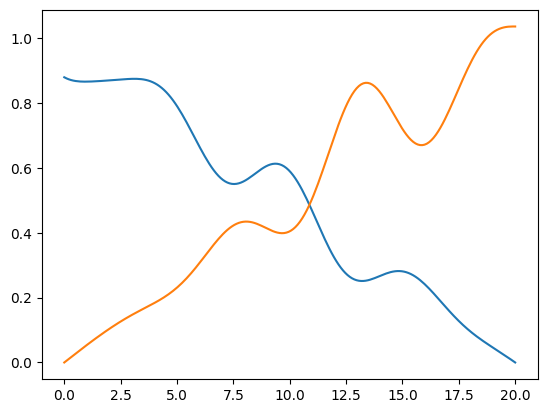

(-2.217374067933819+0j)


In [265]:
# ── energy + state history for both schedules ─────────────────────────────────
energy_linear  = np.zeros(time_steps)
energy_optimal = np.zeros(time_steps)
psi_linear_history  = np.zeros((time_steps, psi_init.shape[0]), dtype=complex)
psi_optimal_history = np.zeros((time_steps, psi_init.shape[0]), dtype=complex)

# optimal
h_driver, h_target = model.get_driving()

# initialize the state
_, psi = eigsh(driver_hamiltonian_s.astype(complex), which='SA', k=1)
psi_init = psi[:, 0].astype(complex)
print(psi_init.dot(h_driver[0]*driver_hamiltonian_s.dot(psi_init)))

plt.plot(time,h_driver)
plt.plot(time,h_target)
plt.show()





# initialization
psi=psi_init.copy()
psi_history_optimalcontrol=np.zeros((time_steps, psi_init.shape[0]), dtype=complex)
for i,t in enumerate(time):
    
    hamiltonian_t=h_driver[i]*driver_hamiltonian_s+target_hamiltonian_s*h_target[i]
    psi=expm_multiply(-1j*delta_t*hamiltonian_t,psi)
    psi_history_optimalcontrol[i]=psi
    #for r in range(nlevels):
    #    probabilities_optimalcontrol[i,r]=(eigenstates_history[i,:,r].conj().T.dot(psi))*np.conjugate((eigenstates_history[i,:,r].conj().T.dot(psi)))

print(psi.conj().dot(target_hamiltonian_s.dot(psi)))

In [86]:


# initialization
energy_optimal=np.zeros(time_steps)
probabilities_optimalcontrol=np.zeros((time_steps,nlevels))
spectrum_optimalcontrol=np.zeros((time_steps,nlevels))
for i,t in enumerate(time):
    psi=psi_history_optimalcontrol[i]     
    hamiltonian_t=(1-t/tau)*driver_hamiltonian_s+target_hamiltonian_s*t/tau
    values, eigenstates = eigsh(hamiltonian_t, which='SA', k=nlevels)
    order = np.argsort(values)
    spectrum_t    = values[order]
    eigenstates_t = eigenstates[:, order]
    spectrum_optimalcontrol[i]=spectrum_t
    # overlap
    probabilities_optimalcontrol[i]=np.einsum('i,ia->a',psi.conj(),eigenstates_t)*np.einsum('i,ia->a',psi.conj(),eigenstates_t).conj()
    energy_optimal[i]=psi.conj().dot(hamiltonian_t.dot(psi))
print(t)
print(psi.conj().dot(target_hamiltonian_s.dot(psi)))
print(probabilities_optimalcontrol[-1,0])

/tmp/ipykernel_50134/2306226813.py:14: ComplexWarning: Casting complex values to real discards the imaginary part
  probabilities_optimalcontrol[i]=np.einsum('i,ia->a',psi.conj(),eigenstates_t)*np.einsum('i,ia->a',psi.conj(),eigenstates_t).conj()
/tmp/ipykernel_50134/2306226813.py:15: ComplexWarning: Casting complex values to real discards the imaginary part
  energy_optimal[i]=psi.conj().dot(hamiltonian_t.dot(psi))


20.0
(-2.7383395241218023+2.220446049250313e-16j)
0.9599961792791386


In [87]:
print(spectrum_optimalcontrol[-1])

[-2.74397661 -2.63081492 -1.8499849  -1.74659578 -1.49125451 -1.38786539
 -1.33488416 -1.23149504 -0.9054462  -0.80205708]


0
-2.743976612213191
1
-2.630814915245384
2
-1.8499848961174559
3
-1.7465957812302024
4
-1.4912545084945676
5
-1.3878653936073166
6
-1.3348841567611414
7
-1.23149504187389
8
-0.905446195859906
9
-0.8020570809726573


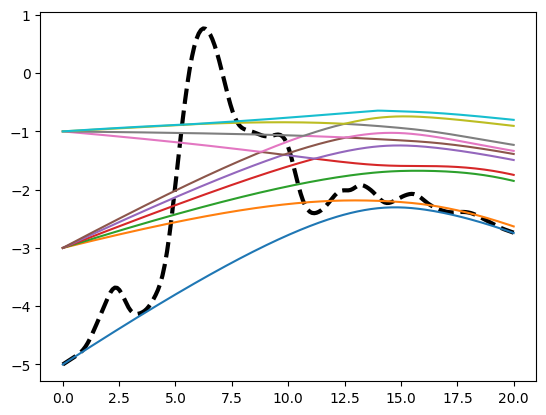

In [88]:

plt.plot(time,energy_optimal,color='black',linestyle='--',linewidth=3)
for i in range(spectrum_optimalcontrol.shape[1]):
        print(i)
        print(spectrum_optimalcontrol[-1,i])
        plt.plot(time,spectrum_optimalcontrol[:,i])

plt.show()

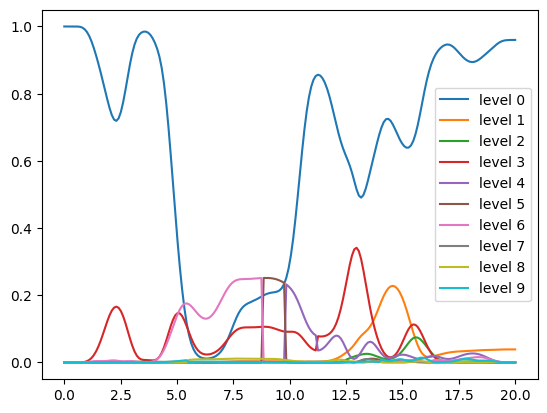

In [89]:
for i in range(nlevels):
    plt.plot(time,probabilities_optimalcontrol[:,i],label=f'level {i}')

plt.legend()
plt.show()

##### Stabilizer Renyi Entropy

In [90]:
# single state
magic_optimal_control=[]
for i in trange(time_steps):
    state=psi_history_optimalcontrol[i]
    magic_optimal_control.append(sre(PS.lift(state)))

  0%|          | 0/200 [00:00<?, ?it/s]

100%|██████████| 200/200 [00:00<00:00, 736.41it/s]


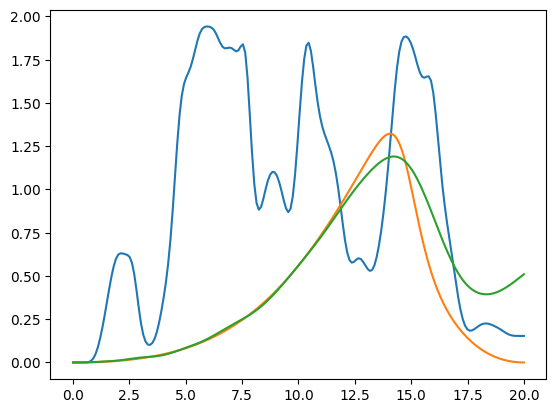

In [91]:
plt.plot(time,magic_optimal_control)
plt.plot(time,magic_gs_level)
plt.plot(time,magic)
plt.show()

## CounterAdiabatic Driving

##### We should be more careful about the CounterAdiabatic Driving, we need to be sure on the structure

Let's initialize the Catalyst term

In [92]:
from src.annealing_utils import get_unbiased_catalyst_term
from src.annealing_utils import get_counteradiabatic_term

counteradiabatic_term=get_counteradiabatic_term(driver_hamiltonian=driver_hamiltonian,target_hamiltonian=target_hamiltonian)
counteradiabatic_term_s=PS.project(counteradiabatic_term)
print(counteradiabatic_term)

<Compressed Sparse Row sparse matrix of dtype 'complex128'
	with 384 stored elements and shape (64, 64)>
  Coords	Values
  (0, 1)	-2.722749550368457j
  (0, 2)	-1.941919531240529j
  (0, 4)	-1.4090924554520456j
  (0, 8)	-2.293311589467222j
  (0, 16)	-1.2527221037186194j
  (0, 32)	-1.356111218605868j
  (1, 0)	2.722749550368457j
  (1, 3)	1.7253687193854739j
  (1, 5)	-1.4090924554520454j
  (1, 9)	-0.5151007393563113j
  (1, 17)	-1.2527221037186191j
  (1, 33)	-1.3561112186058677j
  (2, 0)	1.941919531240529j
  (2, 3)	0.9445387002575463j
  (2, 6)	-1.4090924554520452j
  (2, 10)	-2.293311589467222j
  (2, 18)	-1.2527221037186194j
  (2, 34)	-1.139560406750813j
  (3, 1)	-1.7253687193854739j
  (3, 2)	-0.9445387002575463j
  (3, 7)	-1.4090924554520452j
  (3, 11)	-0.5151007393563114j
  (3, 19)	-1.2527221037186194j
  (3, 35)	-1.139560406750813j
  (4, 0)	1.4090924554520456j
  :	:
  (59, 63)	1.4090924554520456j
  (60, 28)	-1.139560406750813j
  (60, 44)	-1.2527221037186194j
  (60, 52)	-0.5151007393563114j
 

Compute the optimal driving of the adiabatic gauge potential from calculations

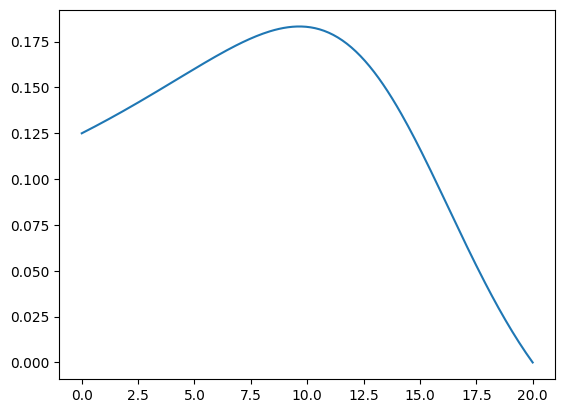

In [ ]:
def optimal_alpha(J, lam):
    """
    Optimal alpha_0(lambda) from minimizing Tr[G_lambda^2].
    """
    J2       = np.sum(J ** 2)                          # ||J||^2
    J2_row   = np.sum(J ** 2, axis=1)                  # (n,): sum_B J_AB^2
    J4_sum   = np.sum(J2_row ** 2)                     # sum_A (sum_B J_AB^2)^2

    numerator   = 4 * (1 - lam) * J2
    denominator = 32 * (1 - lam)**2 * J2 + 16 * lam**2 * J4_sum

    if np.abs(denominator) < 1e-12:
        return 0.0
    return -numerator / denominator

# schedule of alpha_0 along the annealing
alpha = -1*np.array([optimal_alpha(jij, s) for s in time / tau])

plt.plot(time,alpha)
plt.show()

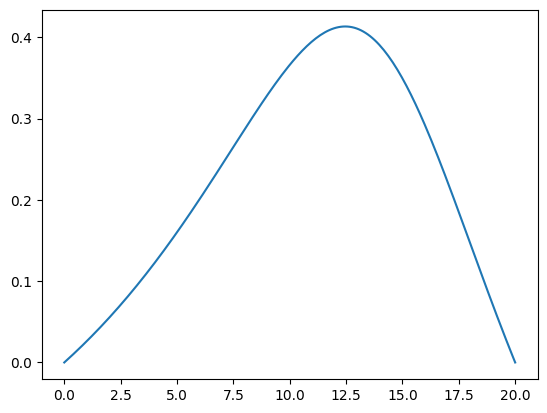

In [250]:
def optimal_alpha(J, lam):
    """
    Optimal alpha_0(lambda) with boundary conditions enforced:
    alpha_0(0) = 0, alpha_0(1) = 0.
    """
    J2     = np.sum(J ** 2)
    J2_row = np.sum(J ** 2, axis=1)
    J4_sum = np.sum(J2_row ** 2)

    numerator   = 4 * (1 - lam) * J2
    denominator = 32 * (1 - lam)**2 * J2 + 16 * lam**2 * J4_sum

    if np.abs(denominator) < 1e-12:
        return 0.0

    alpha_raw = -numerator / denominator

    # enforce boundary conditions: multiply by lambda*(1-lambda)
    return 2*alpha_raw * lam

# schedule of alpha_0 along the annealing
alpha = -2.*np.array([optimal_alpha(jij, s) for s in time / tau])

plt.plot(time,alpha)
plt.show()

In [251]:
from scipy.sparse.linalg import eigsh,expm_multiply

# ── initial state ─────────────────────────────────────────────────────────────
dim      = 2 ** nqubits
psi_init = np.ones(dim, dtype=complex) / np.sqrt(dim)
psi_init=PS.project(psi_init)

# initialization

psi=psi_init.copy()
psi_history_counteradiabatic=np.zeros((time_steps, psi_init.shape[0]), dtype=complex)
spectrum_counteradiabatic=np.zeros((time_steps,nlevels))
energy_counteradiabatic=np.zeros(time_steps)
for i,t in enumerate(time):
    
    hamiltonian_t=(1-t/tau)*driver_hamiltonian_s+target_hamiltonian_s*t/tau+alpha[i]*counteradiabatic_term_s
    psi=expm_multiply(-1j*delta_t*hamiltonian_t,psi)
    spectrum_t,_=eigsh(hamiltonian_t,which='SA',k=nlevels)
    order = np.argsort(spectrum_t)
    spectrum_t    = spectrum_t[order]
    spectrum_counteradiabatic[i]=spectrum_t
    energy_counteradiabatic[i]=psi.conj().dot(hamiltonian_t.dot(psi))
    # sort both by eigenvalue
    psi_history_counteradiabatic[i]=psi


/tmp/ipykernel_50134/2378592107.py:22: ComplexWarning: Casting complex values to real discards the imaginary part
  energy_counteradiabatic[i]=psi.conj().dot(hamiltonian_t.dot(psi))


In [252]:

# initialize the state


# initialization
energy_counteradiabatic_linear_hamiltonian=np.zeros(time_steps)
probabilities_counteradiabatic=np.zeros((time_steps,nlevels))
for i,t in enumerate(time):
    psi=psi_history_counteradiabatic[i]     
    hamiltonian_t_linear=(1-t/tau)*driver_hamiltonian_s+target_hamiltonian_s*t/tau
    values, eigenstates = eigsh(hamiltonian_t_linear, which='SA', k=nlevels)
    order = np.argsort(values)
    spectrum_t    = values[order]
    eigenstates_t = eigenstates[:, order]
    # overlap
    probabilities_counteradiabatic[i]=np.einsum('i,ia->a',psi.conj(),eigenstates_t)*np.einsum('i,ia->a',psi.conj(),eigenstates_t).conj()

    energy_counteradiabatic_linear_hamiltonian[i]=psi.conj().dot(hamiltonian_t_linear.dot(psi))
print(t)
print(psi.conj().dot(target_hamiltonian_s.dot(psi)))
print(energy_counteradiabatic_linear_hamiltonian[-1])
print(probabilities_counteradiabatic[-1,0])

/tmp/ipykernel_50134/1932926314.py:15: ComplexWarning: Casting complex values to real discards the imaginary part
  probabilities_counteradiabatic[i]=np.einsum('i,ia->a',psi.conj(),eigenstates_t)*np.einsum('i,ia->a',psi.conj(),eigenstates_t).conj()
/tmp/ipykernel_50134/1932926314.py:17: ComplexWarning: Casting complex values to real discards the imaginary part
  energy_counteradiabatic_linear_hamiltonian[i]=psi.conj().dot(hamiltonian_t_linear.dot(psi))


20.0
(-2.6379952957703923+0j)
-2.6379952957703923
0.5801356034099505


##### Results of the unbiased counteradiabatic term

0
-2.743976612213183
-2.6379952957703923
1
-2.6308149152453897
-2.6379952957703923
2
-1.8499848961174574
-2.6379952957703923
3
-1.7465957812301984
-2.6379952957703923
4
-1.4912545084945674
-2.6379952957703923
5
-1.3878653936073149
-2.6379952957703923
6
-1.3348841567611416
-2.6379952957703923
7
-1.2314950418738926
-2.6379952957703923
8
-0.9054461958599026
-2.6379952957703923
9
-0.8020570809726572
-2.6379952957703923


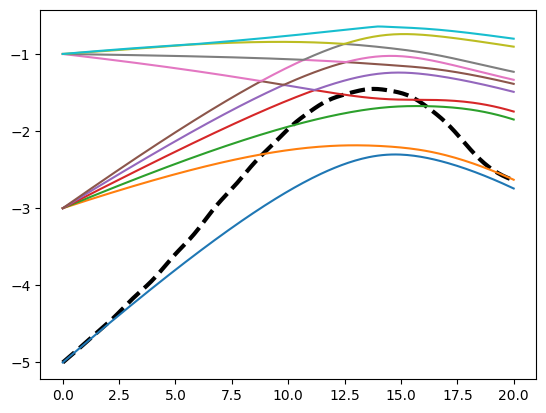

0
-2.7439766122131766
1
-2.630814915245375
2
-1.849984896117448
3
-1.7465957812302049
4
-1.491254508494568
5
-1.3878653936073184
6
-1.3348841567611403
7
-1.231495041873893
8
-0.9054461958599057
9
-0.8020570809726594


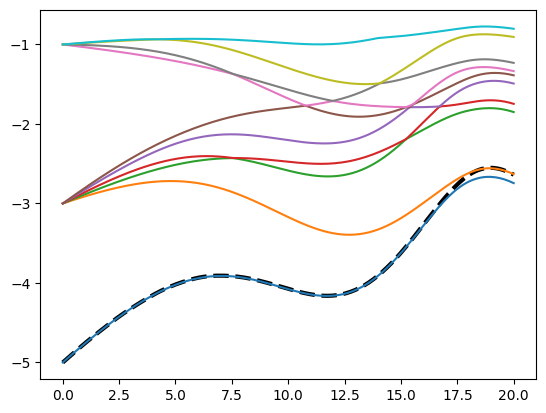

In [253]:

plt.plot(time,energy_counteradiabatic_linear_hamiltonian,color='black',linestyle='--',linewidth=3)
for i in range(spectrum_counteradiabatic.shape[1]):        
        print(i)
        print(spectrum[-1,i])
        print(energy_counteradiabatic_linear_hamiltonian[-1])
        plt.plot(time,spectrum[:,i])

plt.show()

plt.plot(time,energy_counteradiabatic,color='black',linestyle='--',linewidth=3)
for i in range(spectrum_counteradiabatic.shape[1]):

        print(i)
        print(spectrum_counteradiabatic[-1,i])
        plt.plot(time,spectrum_counteradiabatic[:,i])

plt.show()


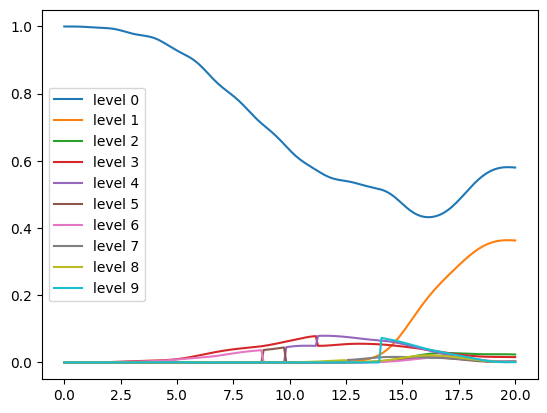

In [254]:
for i in range(nlevels):
    plt.plot(time,probabilities_counteradiabatic[:,i],label=f'level {i}')

plt.legend()
plt.show()

##### Measure of Stabilizerness

In [255]:
# single state
magic_counteradiabatic=[]

for i in trange(time_steps):
    state=psi_history_counteradiabatic[i]
    magic_counteradiabatic.append(sre(PS.lift(state)))


100%|██████████| 200/200 [00:00<00:00, 732.40it/s]


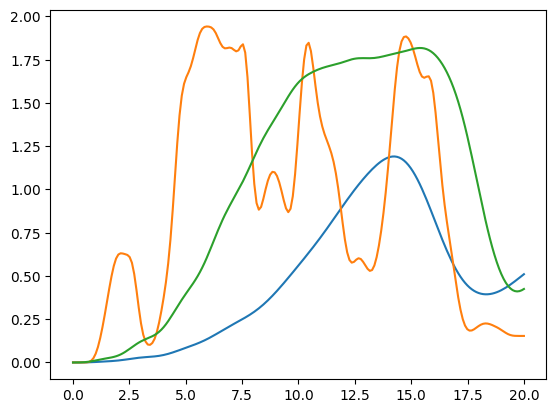

In [256]:
plt.plot(time,magic)
plt.plot(time,magic_optimal_control)
plt.plot(time,magic_counteradiabatic)
plt.show()

## Catalyst Term

##### We should be more careful about the CounterAdiabatic Driving, we need to be sure on the structure

Let's initialize the Catalyst term

In [47]:
from src.annealing_utils import get_unbiased_catalyst_term
from src.annealing_utils import get_counteradiabatic_term
from ManyBodyQutip.qutip_class import SpinOperator

counteradiabatic_term=get_counteradiabatic_term(driver_hamiltonian=driver_hamiltonian,target_hamiltonian=target_hamiltonian)
#catalyst_term=get_unbiased_catalyst_term(nqubits=nqubits)
catalyst_term=SpinOperator(index=[('x',0,'x',nqubits-2)],coupling=[1.],size=nqubits).qutip_op.data_as('csr_matrix')

print(counteradiabatic_term)

<Compressed Sparse Row sparse matrix of dtype 'complex128'
	with 2048 stored elements and shape (256, 256)>
  Coords	Values
  (0, 1)	-2.613077034202336j
  (0, 2)	-2.461921367287011j
  (0, 4)	-2.897776788056897j
  (0, 8)	-1.4190010125549208j
  (0, 16)	-3.5661178048657094j
  (0, 32)	-1.1395065604811117j
  (0, 64)	-2.1627217279081052j
  (0, 128)	-2.7321031512720424j
  (1, 0)	2.613077034202336j
  (1, 3)	-2.46192136728701j
  (1, 5)	-1.5081331158705567j
  (1, 9)	-1.4190010125549206j
  (1, 17)	0.022845255725195024j
  (1, 33)	-0.8919592248536836j
  (1, 65)	-2.162721727908105j
  (1, 129)	-2.732103151272042j
  (2, 0)	2.461921367287011j
  (2, 3)	-2.6130770342023357j
  (2, 6)	0.06574236692946345j
  (2, 10)	-0.9319334647575135j
  (2, 18)	-3.566117804865709j
  (2, 34)	-1.139506560481111j
  (2, 66)	-0.6894656961178518j
  (2, 130)	-2.7321031512720424j
  (3, 1)	2.46192136728701j
  :	:
  (252, 254)	2.46192136728701j
  (253, 125)	-2.7321031512720424j
  (253, 189)	-0.6894656961178518j
  (253, 221)	-1.1395

Tayloring the catalyst around the minimum gap

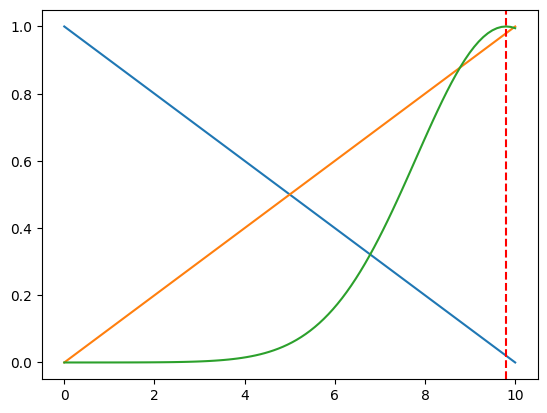

In [48]:
plt.plot(time,(1-time/tau))
plt.plot(time,time/tau)
sigma = 0.2   # width — tune this
catalyst_schedule = np.exp(-0.5 * ((time / tau - (min_time_gap)/tau) / sigma) ** 2)
plt.axvline(x=min_time_gap, color='red', linestyle='--', label='Min Gap Time')
plt.plot(time,catalyst_schedule)
plt.show()

In [60]:
from scipy.sparse.linalg import eigsh,expm_multiply

# ── initial state ─────────────────────────────────────────────────────────────
dim      = 2 ** nqubits
psi_init = np.ones(dim, dtype=complex) / np.sqrt(dim)


# initialization

psi=psi_init
psi_history_catalyst=np.zeros((time_steps, psi_init.shape[0]), dtype=complex)
spectrum_catalyst=np.zeros((time_steps,nlevels))
energy_catalyst=np.zeros(time_steps)
for i,t in enumerate(time):
    
    hamiltonian_t=(1-t/tau)*driver_hamiltonian+target_hamiltonian*t/tau+(1-t/tau)*(t/tau)*catalyst_term
    psi=expm_multiply(-1j*delta_t*hamiltonian_t,psi)
    spectrum_t,_=eigsh(hamiltonian_t,which='SA',k=nlevels)
    order = np.argsort(spectrum_t)
    spectrum_t    = spectrum_t[order]
    spectrum_catalyst[i]=spectrum_t
    energy_catalyst[i]=psi.conj().dot(hamiltonian_t.dot(psi))
    # sort both by eigenvalue
    psi_history_catalyst[i]=psi


/tmp/ipykernel_80040/743221965.py:22: ComplexWarning: Casting complex values to real discards the imaginary part
  energy_catalyst[i]=psi.conj().dot(hamiltonian_t.dot(psi))


In [58]:

# initialize the state


# initialization
energy_catalyst_linear_hamiltonian=np.zeros(time_steps)
probabilities_catalyst=np.zeros((time_steps,nlevels//2))
for i,t in enumerate(time):
    psi=psi_history_catalyst[i]     
    hamiltonian_t_linear=(1-t/tau)*driver_hamiltonian+target_hamiltonian*t/tau
    values, eigenstates = eigsh(hamiltonian_t_linear, which='SA', k=nlevels)
    order = np.argsort(values)
    spectrum_t    = values[order]
    eigenstates_t = eigenstates[:, order]
    # overlap
    overlap_t=np.einsum('i,ia->a',psi.conj(),eigenstates_t)
    for r in range(n_subspaces):
        probabilities_catalyst[i,r]=np.sum(((overlap_t[r*2:(r+1)*2])*(overlap_t[r*2:(r+1)*2]).conj()).real)
    
    energy_catalyst_linear_hamiltonian[i]=psi.conj().dot(hamiltonian_t_linear.dot(psi))
print(t)
print(psi.conj().dot(target_hamiltonian.dot(psi)))
print(probabilities_catalyst[-1,0])

/tmp/ipykernel_80040/4061078792.py:19: ComplexWarning: Casting complex values to real discards the imaginary part
  energy_catalyst_linear_hamiltonian[i]=psi.conj().dot(hamiltonian_t_linear.dot(psi))


10.0
(-3.6324560068402514+2.220446049250313e-16j)
0.2853834343069497


##### Results of the unbiased catalyst

0
-3.9909786558618667
2
-3.9510044159580375
4
-3.878559959173675
6
-3.0590451911043504
8
-2.9548765288788927


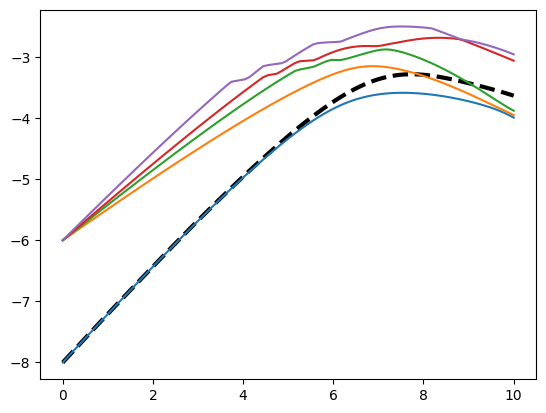

0
-3.990978655861878
2
-3.9510044159580375
4
-3.878559959173677
6
-3.0590451911043464
8
-2.9548765288788905


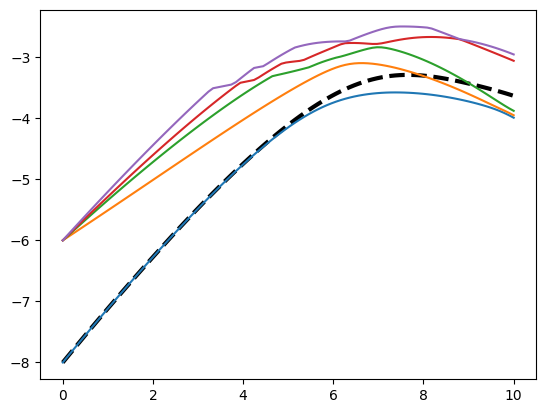

In [59]:

plt.plot(time,energy_catalyst_linear_hamiltonian,color='black',linestyle='--',linewidth=3)
for i in range(spectrum_catalyst.shape[1]):
    if i%2==0:
        print(i)
        print(spectrum[-1,i])
        plt.plot(time,spectrum[:,i])

plt.show()

plt.plot(time,energy_catalyst,color='black',linestyle='--',linewidth=3)
for i in range(spectrum_catalyst.shape[1]):
    if i%2==0:
        print(i)
        print(spectrum_catalyst[-1,i])
        plt.plot(time,spectrum_catalyst[:,i])

plt.show()


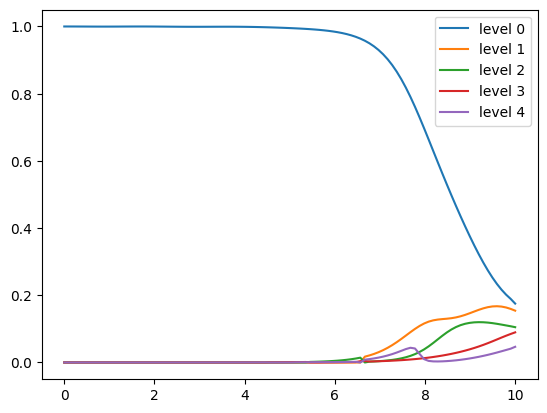

In [95]:
for i in range(nlevels//2):
    plt.plot(time,probabilities_catalyst[:,i],label=f'level {i}')

plt.legend()
plt.show()